# Module 4: Drug Demand Forecasting



## Install Dependencies

In [ ]:
!pip install prophet scikit-learn matplotlib seaborn pandas numpy torch --quiet
print("Dependencies installed.")

Dependencies installed.


##  Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All imports successful!")

All imports successful!


## Load and Explore Dataset

In [ ]:
# Load weekly sales dataset
df = pd.read_csv('salesweekly.csv')
df['datum'] = pd.to_datetime(df['datum'])
df = df.sort_values('datum').reset_index(drop=True)

# All 8 drug categories
DRUG_COLS = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

DRUG_NAMES = {
    'M01AB': 'Anti-inflammatory (M01AB)',
    'M01AE': 'Propionic Acid (M01AE)',
    'N02BA': 'Salicylic Acid (N02BA)',
    'N02BE': 'Anilides/Paracetamol (N02BE)',
    'N05B':  'Anxiolytics (N05B)',
    'N05C':  'Hypnotics/Sedatives (N05C)',
    'R03':   'Airway Drugs (R03)',
    'R06':   'Antihistamines (R06)'
}

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['datum'].min()} to {df['datum'].max()}")
print(f"Total weekly records: {len(df)}")
print(f"Drug columns: {DRUG_COLS}")
print(f"\nMissing values:\n{df[DRUG_COLS].isnull().sum()}")
df.head()

Dataset shape: (302, 9)
Date range: 2014-01-05 00:00:00 to 2019-10-13 00:00:00
Total weekly records: 302
Drug columns: ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

Missing values:
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,2014-01-26,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2014-02-02,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


## Dataset Overview: All Drug Sales Visualization

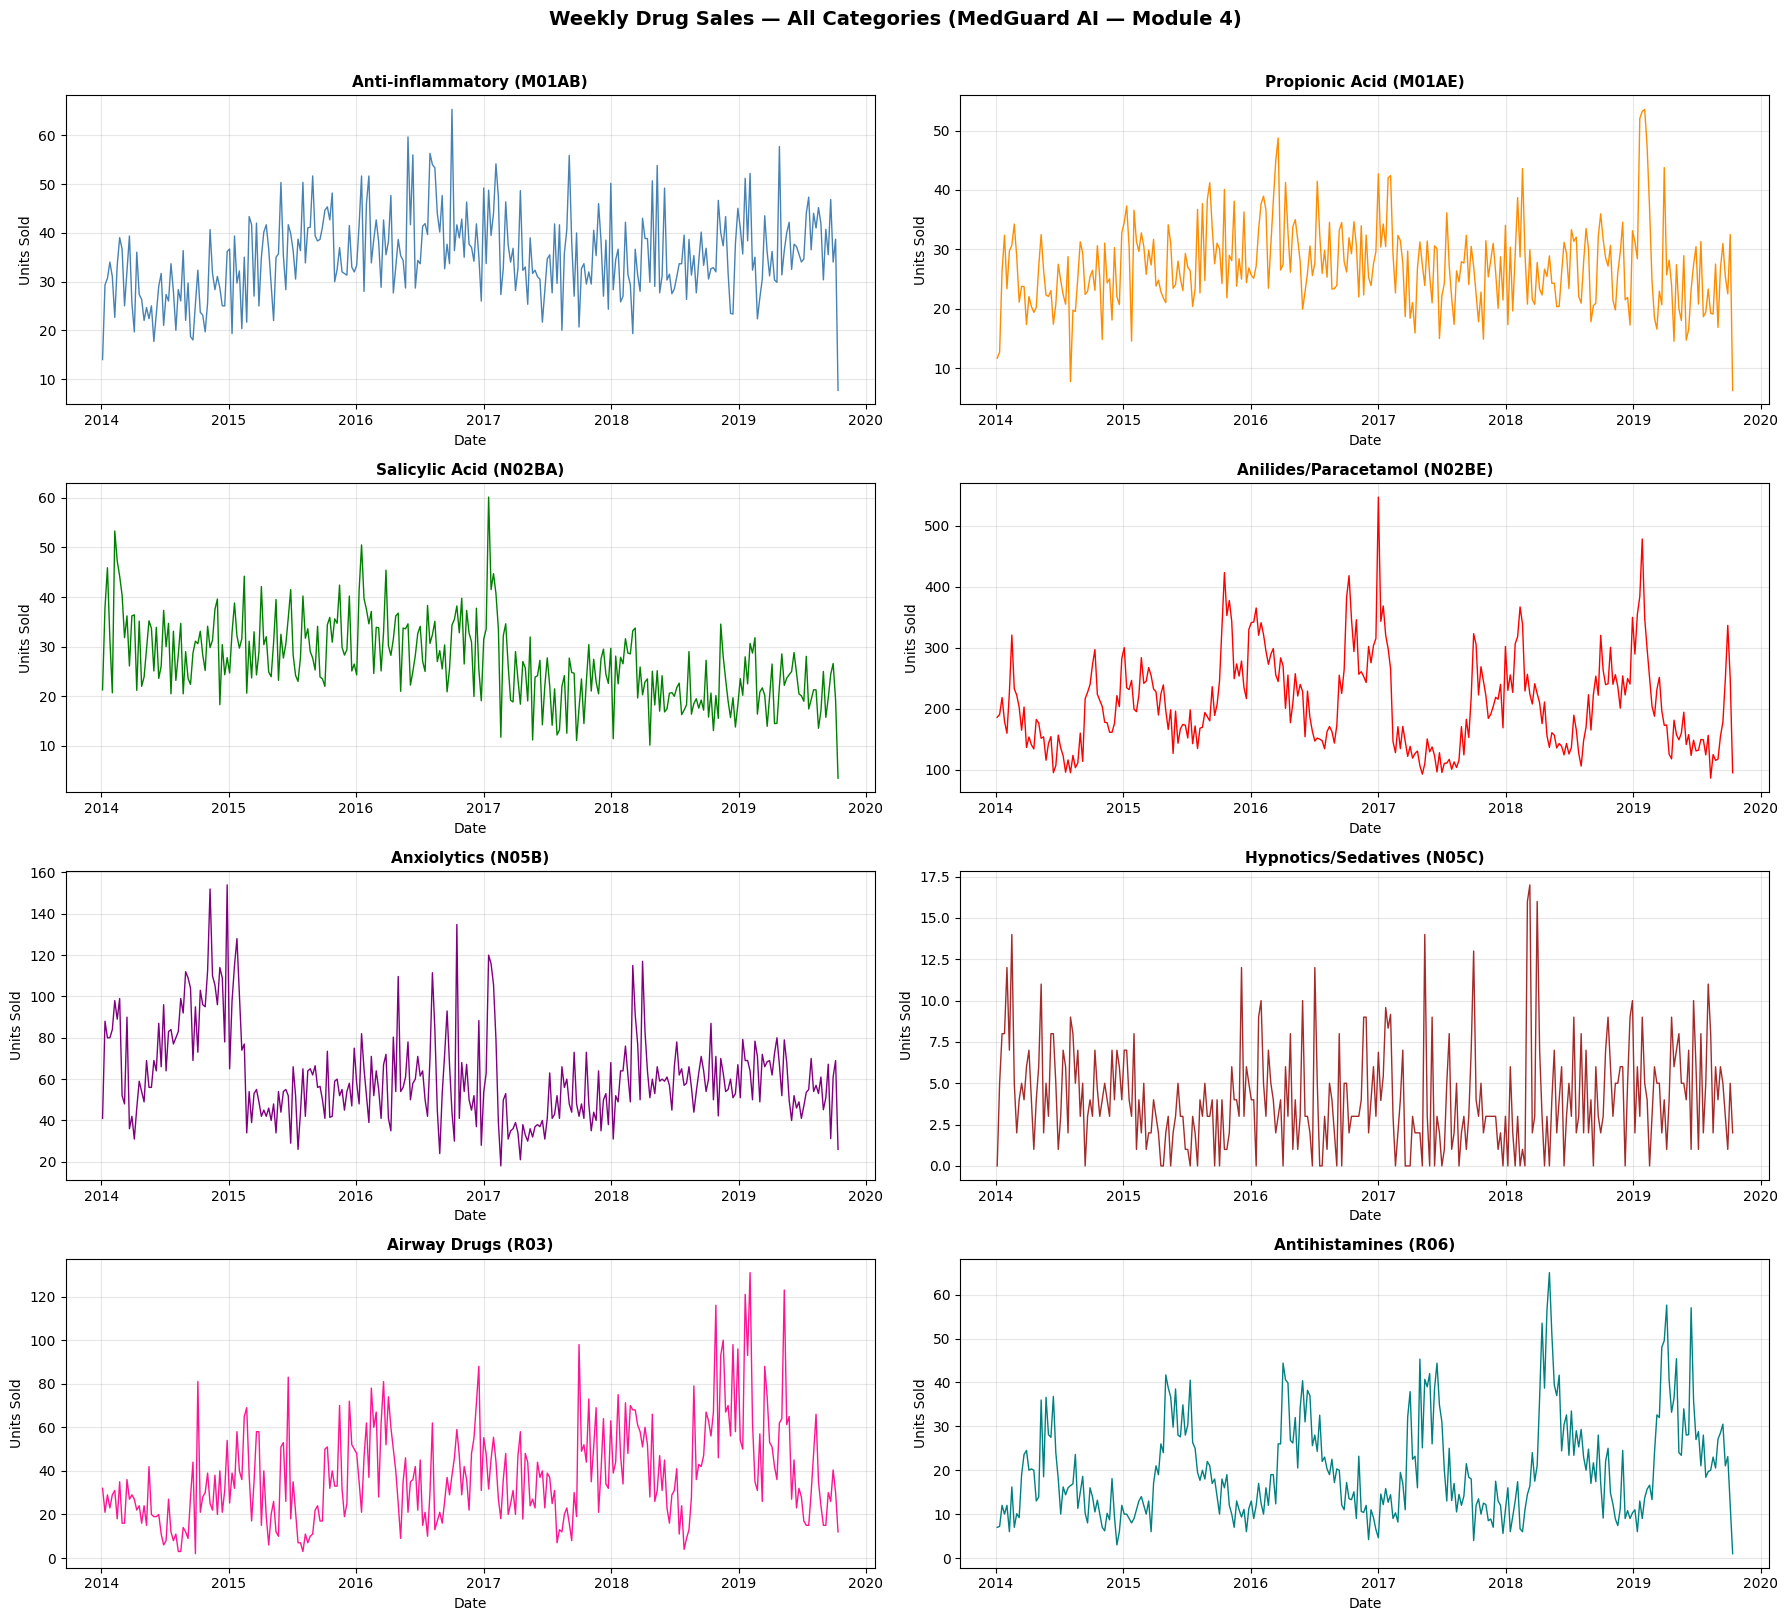

Saved: all_drugs_raw_sales.png


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

colors = ['steelblue','darkorange','green','red','purple','brown','deeppink','teal']

for i, drug in enumerate(DRUG_COLS):
    axes[i].plot(df['datum'], df[drug], color=colors[i], linewidth=1)
    axes[i].set_title(DRUG_NAMES[drug], fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Units Sold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Weekly Drug Sales — All Categories (MedGuard AI — Module 4)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_drugs_raw_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_drugs_raw_sales.png")

## Preprocessing: Handle Missing Values and Outliers

In [ ]:
# Interpolate missing values for all drugs
df[DRUG_COLS] = df[DRUG_COLS].interpolate(method='linear')

# Outlier capping using IQR per drug column
def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for drug in DRUG_COLS:
    df[drug] = cap_outliers(df[drug])

print("Preprocessing complete.")
print(f"Missing values after interpolation:\n{df[DRUG_COLS].isnull().sum()}")
print(f"\nBasic statistics after preprocessing:")
df[DRUG_COLS].describe().round(2)

Preprocessing complete.
Missing values after interpolation:
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64

Basic statistics after preprocessing:


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00
mean,35.08,27.07,27.01,207.84,61.01,4.08,38.06,20.04
std,8.43,6.64,7.90,73.41,20.41,2.94,21.69,10.83
min,13.21,9.40,4.54,86.25,18.00,0.00,2.00,1.00
25%,29.39,22.39,21.30,149.30,47.00,2.00,21.00,11.48
50%,34.56,26.79,26.50,198.30,57.00,3.98,35.00,17.50
75%,40.17,31.05,32.48,252.47,71.00,6.00,51.00,26.00
max,56.36,44.04,49.24,407.23,107.00,12.00,96.00,47.79


## Helper Functions

In [ ]:
# ── Evaluation ──────────────────────────────────────────────
def evaluate(actual, predicted, model_name, drug_name, verbose=True):
    actual    = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # SMAPE — symmetric, handles zero-sales weeks without division explosion
    smape = np.mean(2 * np.abs(actual - predicted) /
                    (np.abs(actual) + np.abs(predicted) + 1e-8)) * 100
    r2    = r2_score(actual, predicted)
    if verbose:
        print(f"  [{model_name}] MAE={mae:.3f} | RMSE={rmse:.3f} | SMAPE={smape:.2f}% | R²={r2:.4f}")
    return {'Drug': drug_name, 'Model': model_name,
            'MAE': round(mae,3), 'RMSE': round(rmse,3),
            'SMAPE(%)': round(smape,2), 'R2': round(r2,4)}

# ── Sequence builder for LSTM/GRU ───────────────────────────
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# ── RNN Model (shared for LSTM and GRU) ─────────────────────
class RNNModel(nn.Module):
    def __init__(self, model_type='LSTM', hidden_size=64, num_layers=2, dropout=0.2):
        super(RNNModel, self).__init__()
        if model_type == 'LSTM':
            self.rnn = nn.LSTM(1, hidden_size, num_layers,
                               dropout=dropout, batch_first=True)
        else:
            self.rnn = nn.GRU(1, hidden_size, num_layers,
                              dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

# ── Training loop (clean single loop with early stopping) ────
def train_rnn(model, X_tr, y_tr, epochs=200, lr=0.001, patience=15):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loader    = DataLoader(TensorDataset(X_tr, y_tr), batch_size=16, shuffle=False)
    best_loss, counter, losses = float('inf'), 0, []
    model.train()
    for epoch in range(epochs):
        ep_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
        avg = ep_loss / len(loader)
        losses.append(avg)
        if avg < best_loss:
            best_loss, counter = avg, 0
        else:
            counter += 1
            if counter >= patience:
                break
    return losses

# ── Prediction ───────────────────────────────────────────────
def predict_rnn(model, X_te, scaler):
    model.eval()
    with torch.no_grad():
        pred = model(X_te).numpy()
    return scaler.inverse_transform(pred).flatten()

print("All helper functions and model class defined.")

All helper functions and model class defined.


## Main Training Loop: All 4 Models × All 8 Drugs

> This cell trains all models for all drug categories and collects results.
> It will take a few minutes to complete — please wait.

In [ ]:
WINDOW     = 8   # Use past 8 weeks to predict next week
TRAIN_RATIO = 0.8

all_results   = []   # Stores evaluation metrics
all_losses    = {}   # Stores training loss curves
all_forecasts = {}   # Stores predictions for plotting

for drug in DRUG_COLS:
    print(f"\n{'='*55}")
    print(f" Training models for: {DRUG_NAMES[drug]}")
    print(f"{'='*55}")

    # ── Prepare data ────────────────────────────────────────
    series = df[['datum', drug]].copy()
    series.columns = ['date', 'sales']

    split = int(len(series) * TRAIN_RATIO)
    train = series[:split].reset_index(drop=True)
    test  = series[split:].reset_index(drop=True)

    # Normalize
    scaler = MinMaxScaler()
    train_sc = scaler.fit_transform(train[['sales']])
    test_sc  = scaler.transform(test[['sales']])
    all_sc   = np.concatenate([train_sc, test_sc])

    # Sequences
    X_all, y_all = create_sequences(all_sc, WINDOW)
    n_train = len(train) - WINDOW
    X_tr, y_tr = X_all[:n_train], y_all[:n_train]
    X_te, y_te = X_all[n_train:], y_all[n_train:]

    X_tr_t = torch.FloatTensor(X_tr).unsqueeze(-1)
    y_tr_t = torch.FloatTensor(y_tr).unsqueeze(-1)
    X_te_t = torch.FloatTensor(X_te).unsqueeze(-1)

    actual = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()
    test_dates = test['date'].values[-len(actual):]

    drug_forecasts = {'dates': test_dates, 'actual': actual}
    drug_losses    = {}

    # ── MODEL 1: Prophet ────────────────────────────────────
    p_train = train.rename(columns={'date':'ds','sales':'y'})
    pm = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                 daily_seasonality=False, seasonality_mode='multiplicative')
    pm.fit(p_train)
    future   = pm.make_future_dataframe(periods=len(test), freq='W')
    forecast = pm.predict(future)
    p_pred   = np.clip(forecast['yhat'].values[-len(test):], 0, None)
    p_pred_aligned = p_pred[-len(actual):]

    all_results.append(evaluate(actual, p_pred_aligned, 'Prophet', drug))
    drug_forecasts['Prophet'] = p_pred_aligned

    # ── MODEL 2: LSTM ───────────────────────────────────────
    lstm = RNNModel('LSTM')
    l_losses = train_rnn(lstm, X_tr_t, y_tr_t)
    l_pred = predict_rnn(lstm, X_te_t, scaler)

    all_results.append(evaluate(actual, l_pred, 'LSTM', drug))
    drug_forecasts['LSTM'] = l_pred
    drug_losses['LSTM']    = l_losses

    # ── MODEL 3: GRU ────────────────────────────────────────
    gru = RNNModel('GRU')
    g_losses = train_rnn(gru, X_tr_t, y_tr_t)
    g_pred = predict_rnn(gru, X_te_t, scaler)

    all_results.append(evaluate(actual, g_pred, 'GRU', drug))
    drug_forecasts['GRU'] = g_pred
    drug_losses['GRU']    = g_losses

    # ── MODEL 4: LSTM + Prophet Hybrid ──────────────────────
    # Step 1: Get Prophet training predictions and residuals
    p_train_pred = np.clip(pm.predict(p_train)['yhat'].values, 0, None)
    residuals    = train['sales'].values - p_train_pred

    # Step 2: Scale residuals using StandardScaler
    # StandardScaler is preferred here because residuals can be negative
    # MinMaxScaler assumes all values are non-negative which distorts the scaling
    from sklearn.preprocessing import StandardScaler
    res_scaler  = StandardScaler()
    res_sc      = res_scaler.fit_transform(residuals.reshape(-1,1))
    res_te_sc   = np.zeros((len(test),1))  # zero residuals for test (unknown)
    res_all_sc  = np.concatenate([res_sc, res_te_sc])

    # Step 3: Create sequences from residuals
    Xr_all, yr_all = create_sequences(res_all_sc, WINDOW)
    Xr_tr = Xr_all[:len(residuals)-WINDOW]
    yr_tr = yr_all[:len(residuals)-WINDOW]
    Xr_te = Xr_all[len(residuals)-WINDOW:]

    Xr_tr_t = torch.FloatTensor(Xr_tr).unsqueeze(-1)
    yr_tr_t = torch.FloatTensor(yr_tr).unsqueeze(-1)
    Xr_te_t = torch.FloatTensor(Xr_te).unsqueeze(-1)

    # Step 4: Train LSTM on residuals
    h_lstm   = RNNModel('LSTM', hidden_size=32)
    h_losses = train_rnn(h_lstm, Xr_tr_t, yr_tr_t)

    # Step 5: Predict residuals
    h_lstm.eval()
    with torch.no_grad():
        res_pred_sc = h_lstm(Xr_te_t).numpy()
    res_pred = res_scaler.inverse_transform(res_pred_sc).flatten()

    # Step 6: Final = Prophet + LSTM residuals
    min_len  = min(len(p_pred_aligned), len(res_pred))
    h_pred   = p_pred_aligned[-min_len:] + res_pred[-min_len:]
    h_actual = actual[-min_len:]

    all_results.append(evaluate(h_actual, h_pred, 'Hybrid', drug))
    drug_forecasts['Hybrid']       = h_pred
    drug_forecasts['hybrid_actual']= h_actual
    drug_forecasts['hybrid_dates'] = test_dates[-min_len:]
    drug_losses['Hybrid']          = h_losses

    all_forecasts[drug] = drug_forecasts
    all_losses[drug]    = drug_losses

print("\n" + "="*55)
print(" All models trained for all drug categories!")
print("="*55)


 Training models for: Anti-inflammatory (M01AB)
  [Prophet] MAE=8.072 | RMSE=9.918 | SMAPE=23.55% | R²=-0.7737
  [LSTM] MAE=5.775 | RMSE=7.823 | SMAPE=16.15% | R²=-0.1036
  [GRU] MAE=5.798 | RMSE=7.886 | SMAPE=16.21% | R²=-0.1216
  [Hybrid] MAE=15.286 | RMSE=16.962 | SMAPE=51.24% | R²=-4.1882

 Training models for: Propionic Acid (M01AE)
  [Prophet] MAE=6.236 | RMSE=7.549 | SMAPE=24.23% | R²=0.0969
  [LSTM] MAE=6.423 | RMSE=7.751 | SMAPE=24.84% | R²=0.0481
  [GRU] MAE=6.371 | RMSE=7.674 | SMAPE=24.68% | R²=0.0669
  [Hybrid] MAE=7.098 | RMSE=8.839 | SMAPE=27.95% | R²=-0.2380

 Training models for: Salicylic Acid (N02BA)
  [Prophet] MAE=5.056 | RMSE=6.307 | SMAPE=25.89% | R²=-0.3988
  [LSTM] MAE=5.069 | RMSE=6.154 | SMAPE=24.31% | R²=-0.3315
  [GRU] MAE=4.716 | RMSE=5.829 | SMAPE=22.74% | R²=-0.1948
  [Hybrid] MAE=4.532 | RMSE=5.648 | SMAPE=22.51% | R²=-0.1217

 Training models for: Anilides/Paracetamol (N02BE)
  [Prophet] MAE=51.627 | RMSE=68.386 | SMAPE=24.13% | R²=0.1613
  [LSTM] MAE

## Results Table: All Models × All Drugs

In [ ]:
results_df = pd.DataFrame(all_results)

# Pivot for clean display
pivot_mae = results_df.pivot(index='Drug', columns='Model', values='MAE').round(3)
pivot_r2  = results_df.pivot(index='Drug', columns='Model', values='R2').round(4)

print("\n" + "="*70)
print("  FULL RESULTS TABLE — MAE per Drug per Model")
print("="*70)
print(pivot_mae.to_string())

print("\n" + "="*70)
print("  FULL RESULTS TABLE — R² per Drug per Model")
print("="*70)
print(pivot_r2.to_string())

print("\n" + "="*70)
print("  AVERAGE METRICS ACROSS ALL DRUGS")
print("="*70)
avg = results_df.groupby('Model')[['MAE','RMSE','SMAPE(%)','R2']].mean().round(3)
print(avg.to_string())

best = avg['MAE'].idxmin()
print(f"\n  Best Overall Model (lowest avg MAE): {best}")


  FULL RESULTS TABLE — MAE per Drug per Model
Model     GRU  Hybrid    LSTM  Prophet
Drug                                  
M01AB   5.798  15.286   5.775    8.072
M01AE   6.371   7.098   6.423    6.236
N02BA   4.716   4.532   5.069    5.056
N02BE  35.990  49.397  37.642   51.627
N05B   10.117  12.127   9.497   11.658
N05C    2.302   2.274   2.321    2.664
R03    17.361  19.761  17.468   19.672
R06     5.900   6.343   6.044    5.882

  FULL RESULTS TABLE — R² per Drug per Model
Model     GRU  Hybrid    LSTM  Prophet
Drug                                  
M01AB -0.1216 -4.1882 -0.1036  -0.7737
M01AE  0.0669 -0.2380  0.0481   0.0969
N02BA -0.1948 -0.1217 -0.3315  -0.3988
N02BE  0.6000  0.2001  0.5597   0.1613
N05B  -0.0724 -0.7273  0.0260  -0.5657
N05C  -0.1298 -0.1468 -0.1493  -0.5732
R03    0.2324  0.0279  0.2245   0.0098
R06    0.5623  0.4820  0.5454   0.4943

  AVERAGE METRICS ACROSS ALL DRUGS
            MAE    RMSE  SMAPE(%)     R2
Model                                   
GRU      

## Heatmap: MAE Across All Drugs and Models

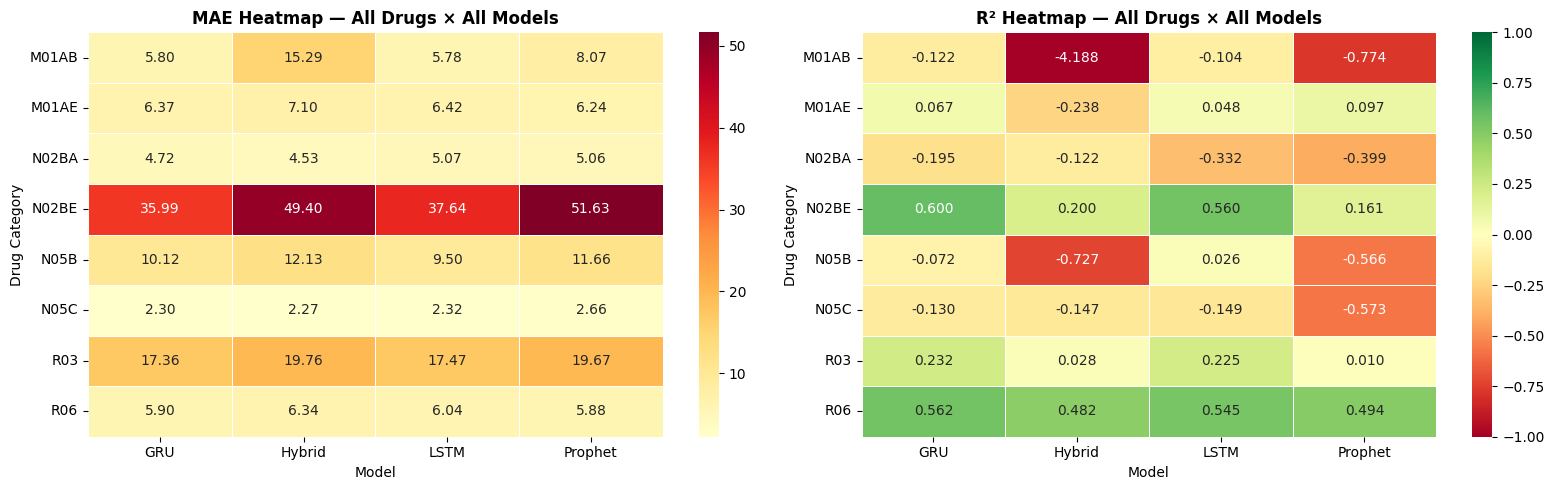

Saved: heatmap_mae_r2.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MAE Heatmap
sns.heatmap(pivot_mae, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('MAE Heatmap — All Drugs × All Models', fontweight='bold')
axes[0].set_xlabel('Model'); axes[0].set_ylabel('Drug Category')

# R² Heatmap
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title('R² Heatmap — All Drugs × All Models', fontweight='bold')
axes[1].set_xlabel('Model'); axes[1].set_ylabel('Drug Category')

plt.tight_layout()
plt.savefig('heatmap_mae_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: heatmap_mae_r2.png")

## Average Metric Comparison Bar Chart

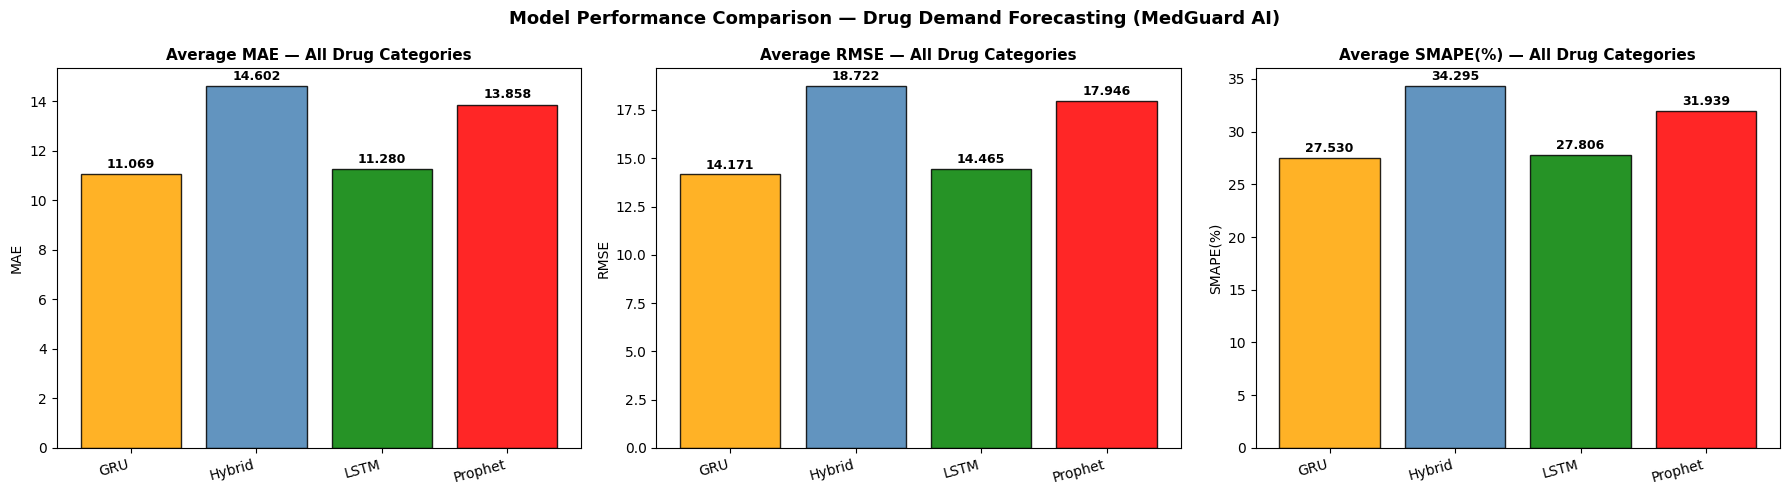

Saved: avg_metric_comparison.png


In [ ]:
metrics  = ['MAE', 'RMSE', 'SMAPE(%)']
m_colors = ['orange', 'steelblue', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    vals  = avg[metric]
    bars  = ax.bar(vals.index, vals.values, color=m_colors, alpha=0.85, edgecolor='black')
    ax.set_title(f'Average {metric} — All Drug Categories', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(vals.index, rotation=15, ha='right')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 * bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison — Drug Demand Forecasting (MedGuard AI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('avg_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: avg_metric_comparison.png")

##  Actual vs Predicted: All Models for All 8 Drugs

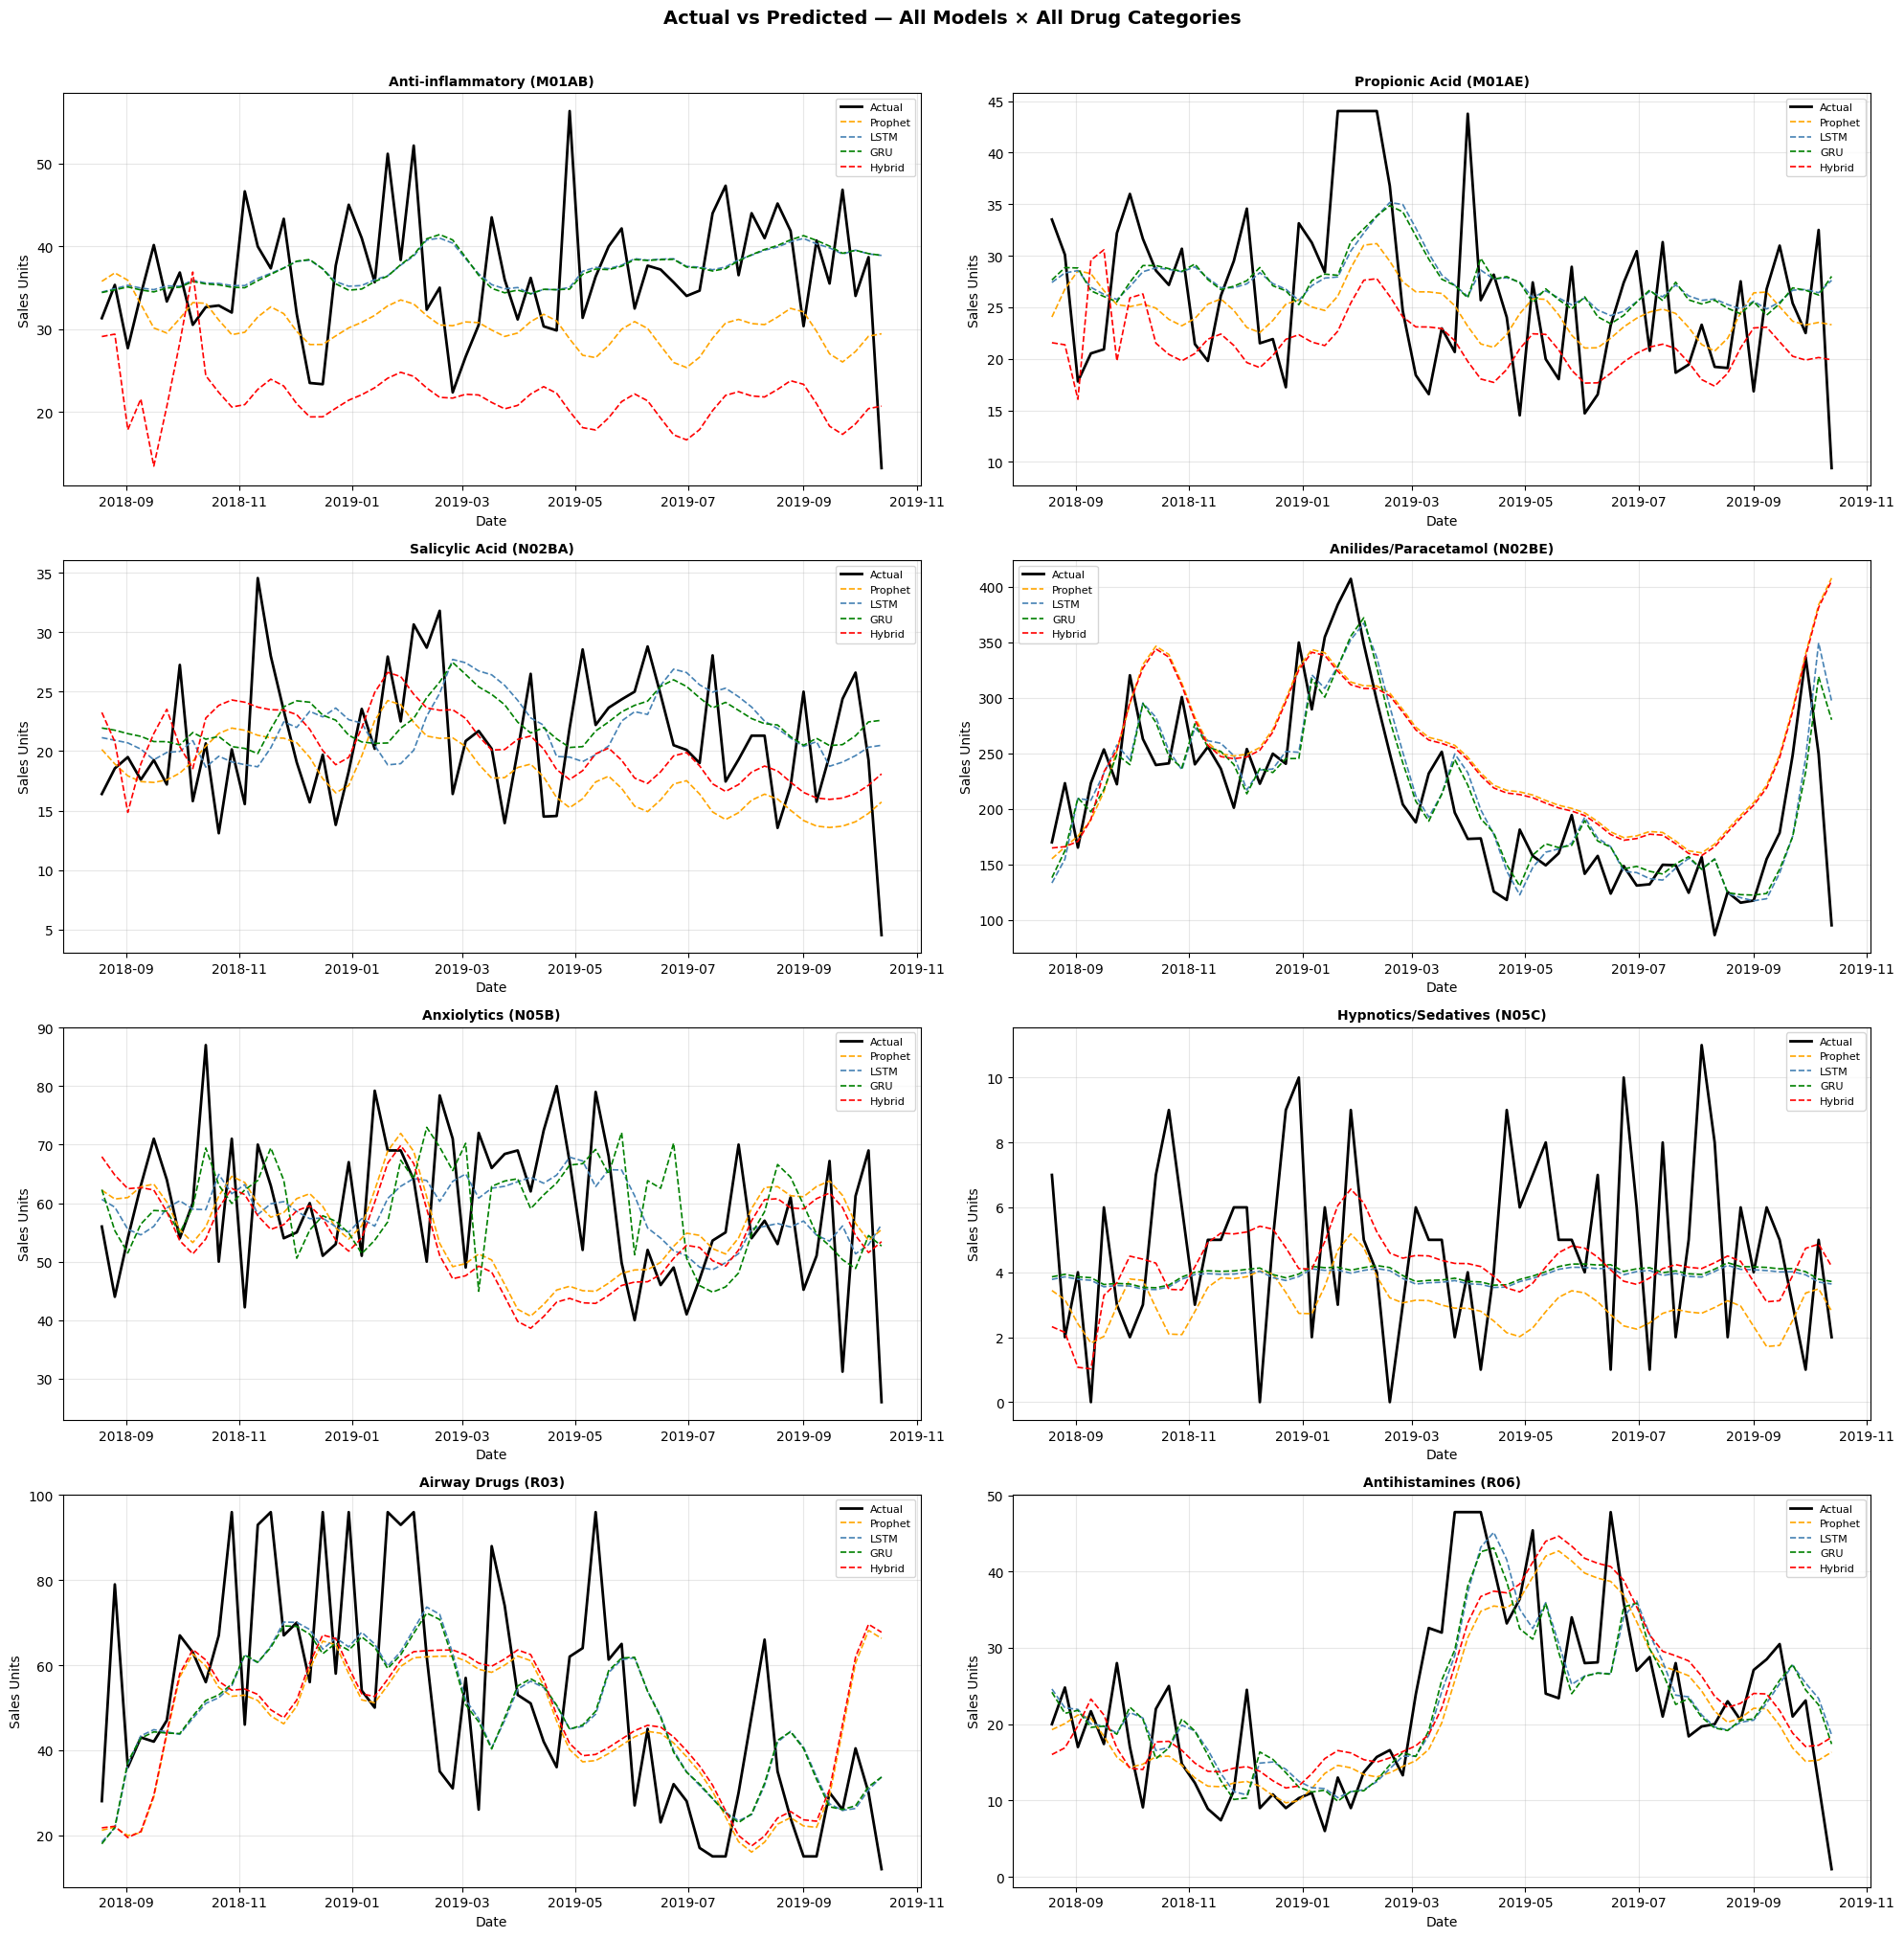

Saved: all_drugs_forecast_comparison.png


In [ ]:
model_colors = {'Prophet':'orange', 'LSTM':'steelblue', 'GRU':'green', 'Hybrid':'red'}

fig, axes = plt.subplots(4, 2, figsize=(20, 20))
axes = axes.flatten()

for i, drug in enumerate(DRUG_COLS):
    fc  = all_forecasts[drug]
    ax  = axes[i]
    dates  = fc['dates']
    actual = fc['actual']

    ax.plot(dates, actual, label='Actual', color='black', linewidth=2)

    for model, color in model_colors.items():
        if model == 'Hybrid':
            ax.plot(fc['hybrid_dates'], fc['Hybrid'],
                    label='Hybrid', color=color, linestyle='--', linewidth=1.2)
        else:
            pred = fc.get(model)
            if pred is not None:
                ax.plot(dates[-len(pred):], pred,
                        label=model, color=color, linestyle='--', linewidth=1.2)

    ax.set_title(DRUG_NAMES[drug], fontsize=10, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Sales Units')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted — All Models × All Drug Categories',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_drugs_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_drugs_forecast_comparison.png")

## Training Loss Curves: LSTM and GRU for All Drugs

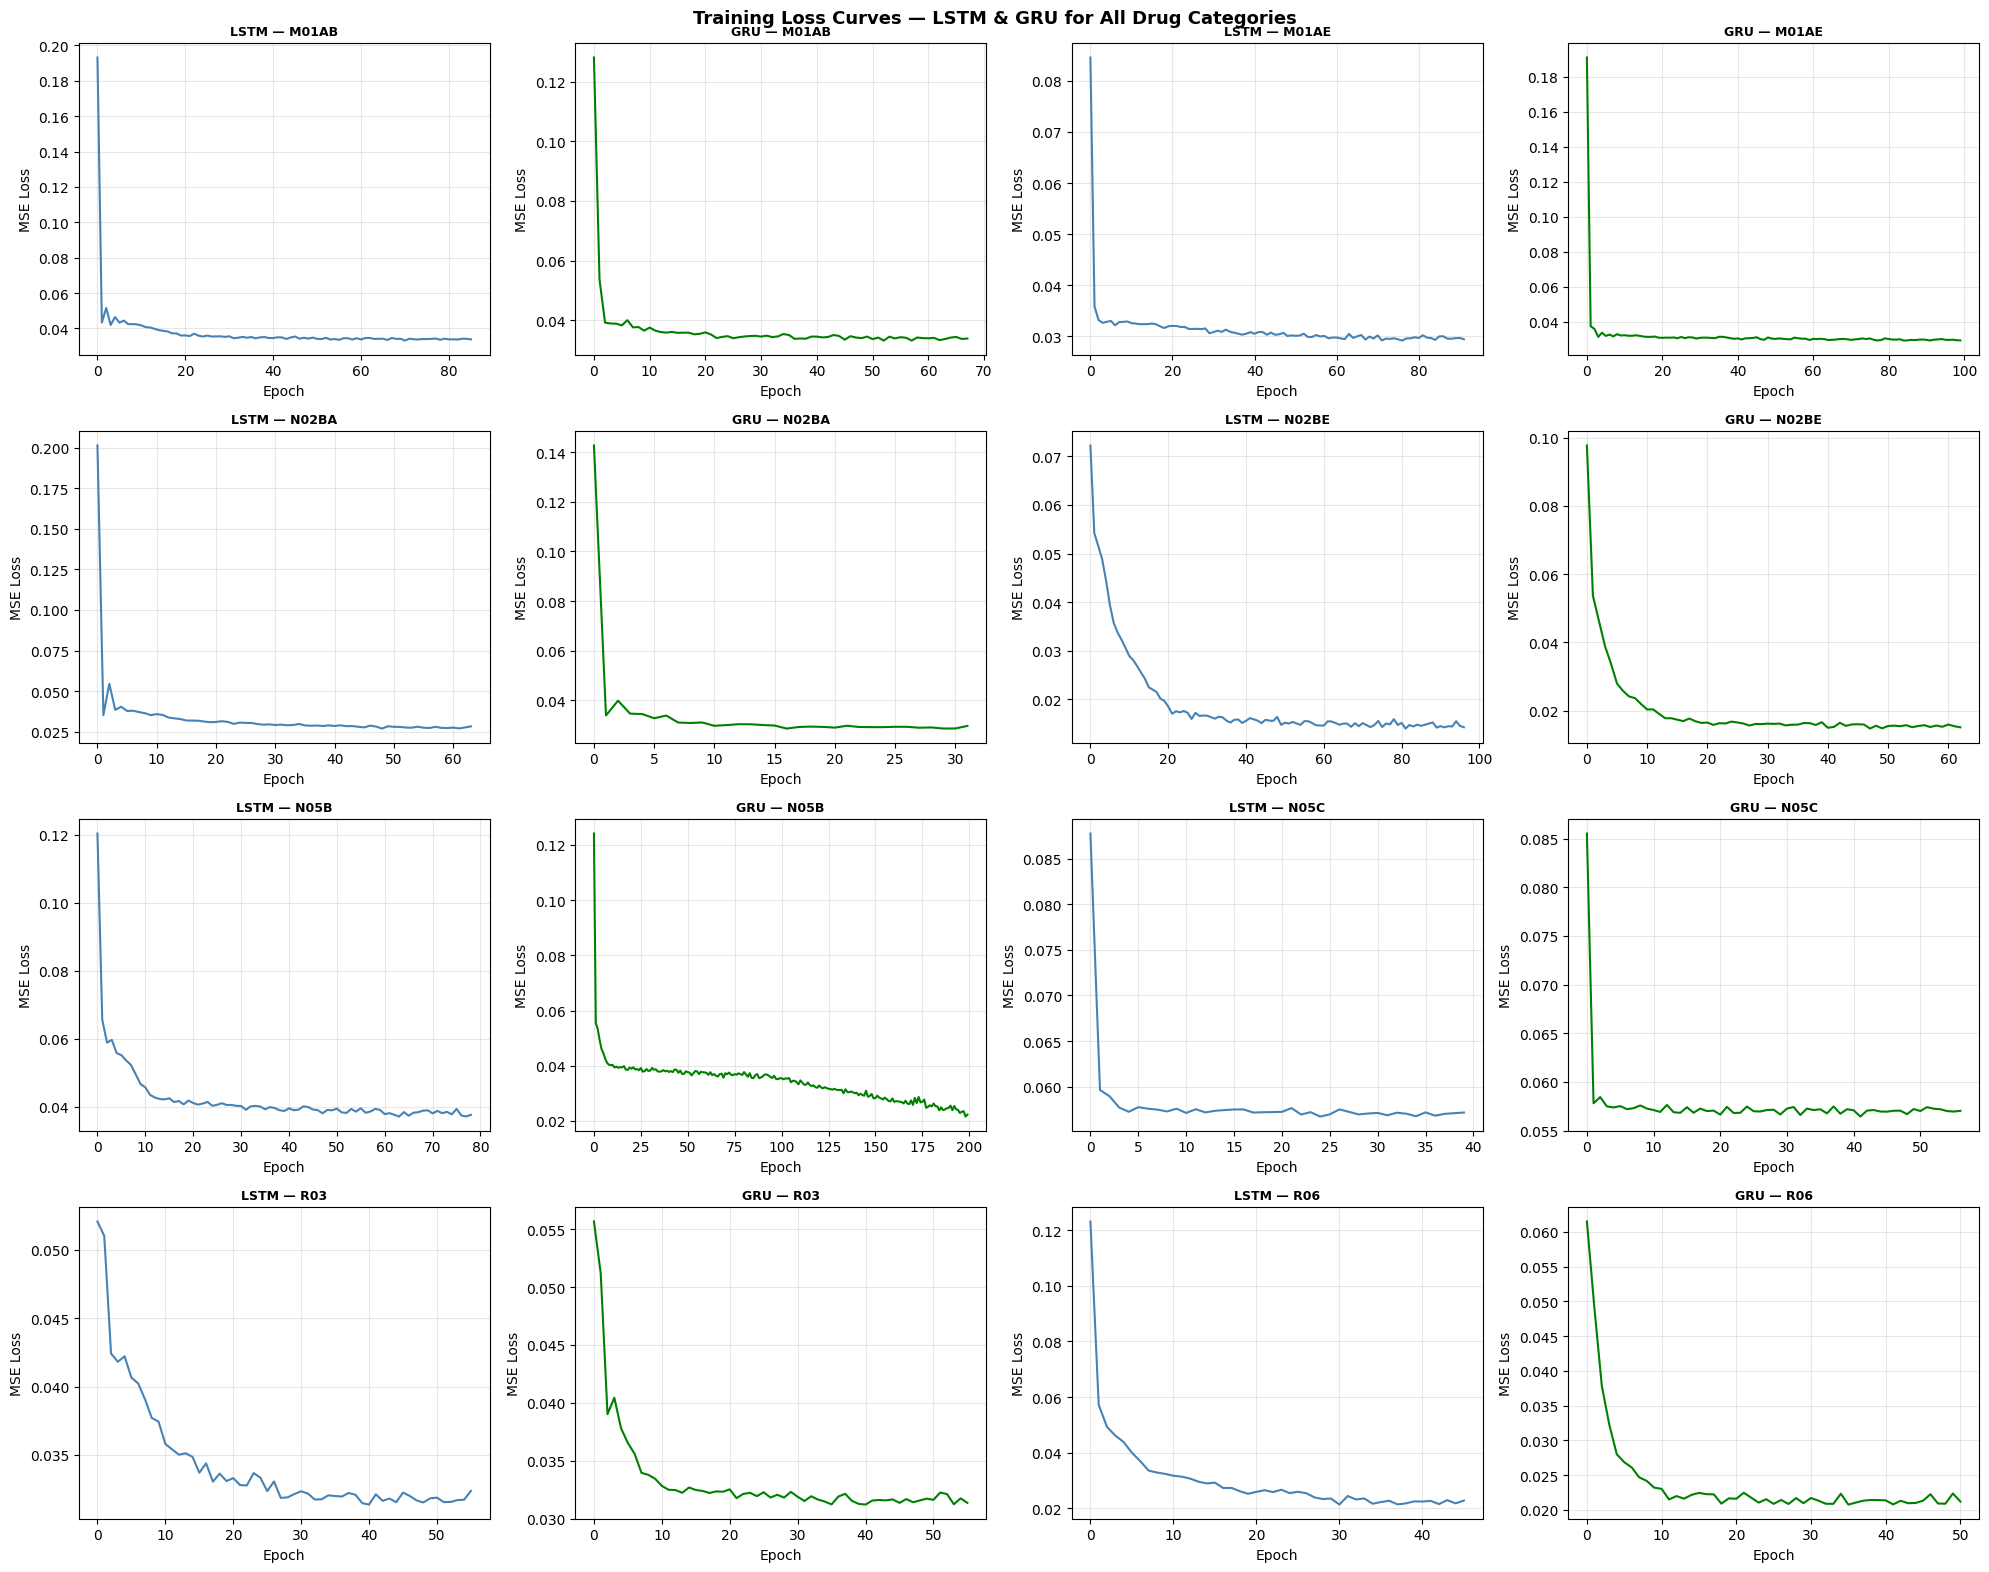

Saved: training_loss_all_drugs.png


In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

idx = 0
for drug in DRUG_COLS:
    for model in ['LSTM', 'GRU']:
        losses = all_losses[drug][model]
        color  = 'steelblue' if model == 'LSTM' else 'green'
        axes[idx].plot(losses, color=color, linewidth=1.5)
        axes[idx].set_title(f'{model} — {drug}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Epoch'); axes[idx].set_ylabel('MSE Loss')
        axes[idx].grid(True, alpha=0.3)
        idx += 1

plt.suptitle('Training Loss Curves — LSTM & GRU for All Drug Categories',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_loss_all_drugs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_loss_all_drugs.png")

## R² Score Comparison Across All Drugs

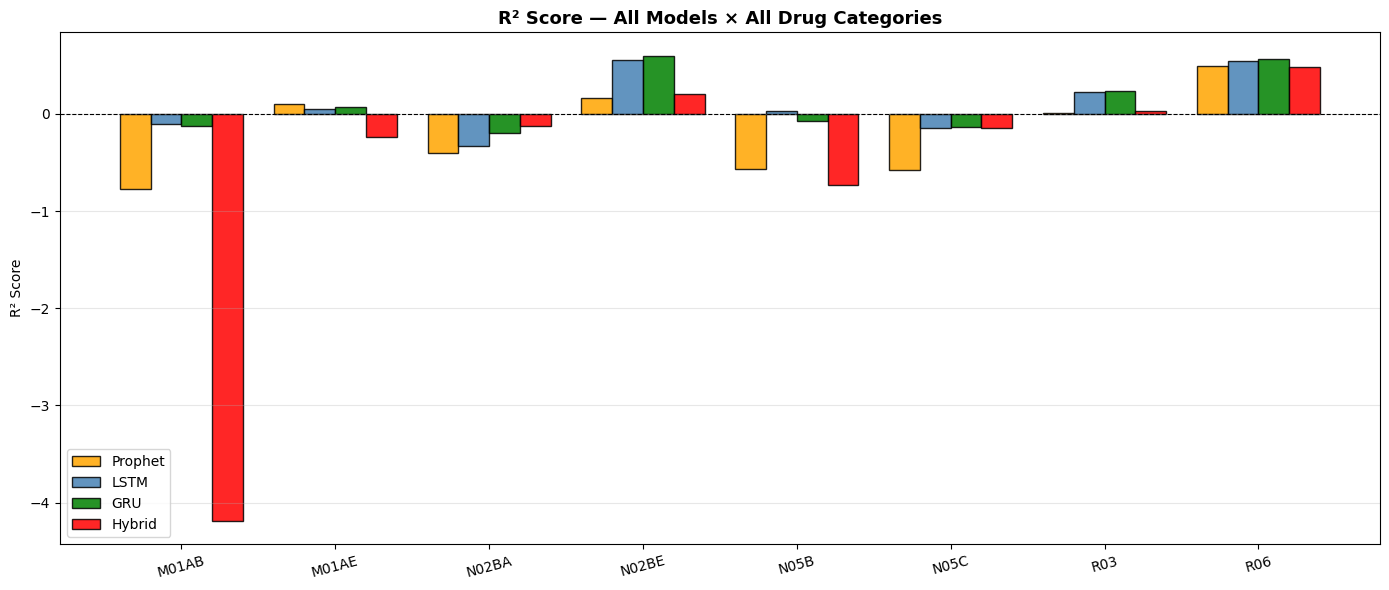

Saved: r2_all_drugs.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

x       = np.arange(len(DRUG_COLS))
width   = 0.2
models  = ['Prophet', 'LSTM', 'GRU', 'Hybrid']
offsets = [-1.5, -0.5, 0.5, 1.5]

for model, offset, color in zip(models, offsets, m_colors):
    r2_vals = [results_df[(results_df['Drug']==d) &
                          (results_df['Model']==model)]['R2'].values[0]
               for d in DRUG_COLS]
    ax.bar(x + offset*width, r2_vals, width, label=model,
           color=color, alpha=0.85, edgecolor='black')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(DRUG_COLS, rotation=15)
ax.set_ylabel('R² Score')
ax.set_title('R² Score — All Models × All Drug Categories', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('r2_all_drugs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: r2_all_drugs.png")

##  Per-Drug Best Model Summary

In [ ]:
print("\n" + "="*60)
print("  BEST MODEL PER DRUG CATEGORY (by lowest MAE)")
print("="*60)

best_per_drug = []
for drug in DRUG_COLS:
    drug_res = results_df[results_df['Drug'] == drug]
    best_row = drug_res.loc[drug_res['MAE'].idxmin()]
    best_per_drug.append({
        'Drug': drug,
        'Full Name': DRUG_NAMES[drug],
        'Best Model': best_row['Model'],
        'MAE': best_row['MAE'],
        'RMSE': best_row['RMSE'],
        'SMAPE(%)': best_row['SMAPE(%)'],
        'R²': best_row['R2']
    })

best_df = pd.DataFrame(best_per_drug)
print(best_df.to_string(index=False))

# Count wins per model
print("\n  Model Win Count:")
print(best_df['Best Model'].value_counts().to_string())


  BEST MODEL PER DRUG CATEGORY (by lowest MAE)
 Drug                    Full Name Best Model    MAE   RMSE  SMAPE(%)      R²
M01AB    Anti-inflammatory (M01AB)       LSTM  5.775  7.823     16.15 -0.1036
M01AE       Propionic Acid (M01AE)    Prophet  6.236  7.549     24.23  0.0969
N02BA       Salicylic Acid (N02BA)     Hybrid  4.532  5.648     22.51 -0.1217
N02BE Anilides/Paracetamol (N02BE)        GRU 35.990 47.225     17.30  0.6000
 N05B           Anxiolytics (N05B)       LSTM  9.497 11.912     16.53  0.0260
 N05C   Hypnotics/Sedatives (N05C)     Hybrid  2.274  2.853     56.36 -0.1468
  R03           Airway Drugs (R03)        GRU 17.361 21.987     36.25  0.2324
  R06         Antihistamines (R06)    Prophet  5.882  7.988     27.36  0.4943

  Model Win Count:
Best Model
LSTM       2
Prophet    2
Hybrid     2
GRU        2


## Export Full Results to CSV (for Thesis)

In [ ]:
results_df.to_csv('module4_full_results.csv', index=False)
best_df.to_csv('module4_best_per_drug.csv', index=False)
avg.to_csv('module4_avg_metrics.csv')

print("Results exported:")
print("  module4_full_results.csv  — All metrics for all models and drugs")
print("  module4_best_per_drug.csv — Best model per drug category")
print("  module4_avg_metrics.csv   — Average metrics per model")

Results exported:
  module4_full_results.csv  — All metrics for all models and drugs
  module4_best_per_drug.csv — Best model per drug category
  module4_avg_metrics.csv   — Average metrics per model


## Gradio Interface: Interactive Drug Demand Forecasting

In [ ]:
!pip install gradio --quiet

In [ ]:
import gradio as gr
import io, base64

def forecast_drug(drug_col, model_name):
    try:
        fc = all_forecasts[drug_col]
        dates  = fc['dates']
        actual = fc['actual']

        if model_name == 'Hybrid':
            pred   = fc['Hybrid']
            dates  = fc['hybrid_dates']
            actual = fc['hybrid_actual']
        else:
            pred = fc[model_name]
            pred_len = min(len(dates), len(pred))
            dates  = dates[-pred_len:]
            actual = actual[-pred_len:]
            pred   = pred[-pred_len:]

        # Get metrics
        row = results_df[(results_df['Drug']==drug_col) &
                         (results_df['Model']==model_name)].iloc[0]

        # Plot
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(dates, actual, label='Actual Sales', color='black', linewidth=2)
        ax.plot(dates, pred, label=f'{model_name} Forecast',
                color='red', linestyle='--', linewidth=2)
        ax.fill_between(dates,
                        np.array(pred) * 0.9,
                        np.array(pred) * 1.1,
                        alpha=0.15, color='red', label='±10% Confidence Band')
        ax.set_title(f'{DRUG_NAMES[drug_col]} — {model_name} Forecast',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Date'); ax.set_ylabel('Units Sold')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()

        metrics_text = (
            f"Drug     : {DRUG_NAMES[drug_col]}\n"
            f"Model    : {model_name}\n"
            f"━━━━━━━━━━━━━━━━━━━━━━\n"
            f"MAE      : {row['MAE']:.3f}\n"
            f"RMSE     : {row['RMSE']:.3f}\n"
            f"MAPE     : {row['SMAPE(%)']:.2f}%\n"
            f"R²       : {row['R2']:.4f}\n"
        )

        return fig, metrics_text

    except Exception as e:
        return None, f"Error: {str(e)}"


with gr.Blocks(title="MedGuard AI — Drug Demand Forecasting") as demo:
    gr.Markdown("""
    # 💊 MedGuard AI — Module 4: Drug Demand Forecasting
    Select a drug category and forecasting model to view predictions and evaluation metrics.
    """)

    with gr.Row():
        drug_input  = gr.Dropdown(
            choices=DRUG_COLS,
            value='M01AB',
            label='Drug Category'
        )
        model_input = gr.Dropdown(
            choices=['Prophet', 'LSTM', 'GRU', 'Hybrid'],
            value='Hybrid',
            label='Forecasting Model'
        )
        btn = gr.Button("Generate Forecast", variant='primary')

    with gr.Row():
        plot_out    = gr.Plot(label='Forecast Plot')
        metrics_out = gr.Textbox(label='Evaluation Metrics', lines=10)

    btn.click(
        fn=forecast_drug,
        inputs=[drug_input, model_input],
        outputs=[plot_out, metrics_out]
    )

    gr.Markdown("""
    **Models:** Prophet | LSTM | GRU | LSTM+Prophet Hybrid
    **Student:** Mohideen Mohamed Rushdi | RGU ID: 2237950
    """)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f629d63c1a56d442da.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
